In [74]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk
import rsp.data_processing.signal_processing as signal_processing

from rsp.plotting import Rsp_Kit

def analyze_and_plot_breathing(h5_file, target_rate=100):
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
    except Exception as e:
        return {"file": os.path.basename(h5_file), "error": str(e)}

    try:
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except KeyError:
        return {"file": os.path.basename(h5_file), "error": "Missing 'duration_sec' metadata"}

    # Step 1: Pre-downsampling apply low-pass filter
    cutoff_hz = target_rate / 2
    nyquist = fs / 2
    norm_cutoff = cutoff_hz / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Step 2: Downsample
    downsample_factor = int(fs // target_rate)
    downsampled_resp = resample_poly(filtered_resp, up=1, down=downsample_factor)
    duration_downsampled = len(downsampled_resp) / target_rate

    # Step 3: Apply neurokit2 Butterworth bandpass filter after downsampling
    rsp_cleaned = nk.signal_filter(
        downsampled_resp,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Step 4: Mask signal loss with NaN values
    signal_loss_filtered = signal_processing.mask_signal_loss(
        rsp_cleaned,
        fs=target_rate,
        window_sec=10,
        std_thresh=500,
    )

    # Step 5: Subtract total time NaNed from total duration
    total_nan_time = np.sum(np.isnan(signal_loss_filtered)) / target_rate
    duration_downsampled -= total_nan_time

    # Step 6: Peak detection | Change to match how class finds peaks
    # Find valid (non-NaN) indices
    valid = ~np.isnan(signal_loss_filtered)

    # Run peak detection only on valid values
    valid_signal = signal_loss_filtered[valid]
    peaks_valid, _ = find_peaks(valid_signal, distance=target_rate // 20)

    # Calculate valid duration again (just to be sure)
    duration_valid = np.sum(valid) / target_rate
    breathing_rate_hz = len(peaks_valid) / duration_valid

    # Step 7: Plot with Rsp_Kit
    try:
        rsp_obj = Rsp_Kit.Rsp_Kit(valid_signal, fs=target_rate, n_samples=len(valid_signal))
        fig = rsp_obj.plot(duration=600, show_peaks=True, title=os.path.basename(h5_file))
        plt.close()
    except Exception as plot_err:
        return {"file": os.path.basename(h5_file), "error": f"Plotting failed: {plot_err}"}

    return {
        "file": os.path.basename(h5_file),
        "original_fs": round(fs, 2),
        "duration_sec (before downsample and filtering)": round(duration_sec, 2),
        "downsampled_len": len(downsampled_resp),
        "duration_valid": round(duration_downsampled, 2),
        "peak_count": len(peaks_valid),
        "breathing_rate_hz": round(breathing_rate_hz, 2),
    }

In [75]:
import importlib

# Ensure the module is reloaded to reflect any changes
importlib.reload(signal_processing)

<module 'rsp.data_processing.signal_processing' from 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\src\\rsp\\data_processing\\signal_processing.py'>

Checking window 0.00s to 10.00s with std 903.2968
Checking window 10.00s to 20.00s with std 892.0208
Checking window 20.00s to 30.00s with std 988.1541
Checking window 30.00s to 40.00s with std 760.5279
Checking window 40.00s to 50.00s with std 902.2334
Checking window 50.00s to 60.00s with std 701.2667
Checking window 60.00s to 70.00s with std 900.9809
Checking window 70.00s to 80.00s with std 913.1767
Checking window 80.00s to 90.00s with std 890.9042
Checking window 90.00s to 100.00s with std 848.5702
Checking window 100.00s to 110.00s with std 835.4617
Checking window 110.00s to 120.00s with std 786.6001
Checking window 120.00s to 130.00s with std 836.6391
Checking window 130.00s to 140.00s with std 749.6258
Checking window 140.00s to 150.00s with std 465.5968
Checking window 150.00s to 160.00s with std 881.8192
Checking window 160.00s to 170.00s with std 935.0325
Checking window 170.00s to 180.00s with std 895.3955
Checking window 180.00s to 190.00s with std 655.9242
Checking wind

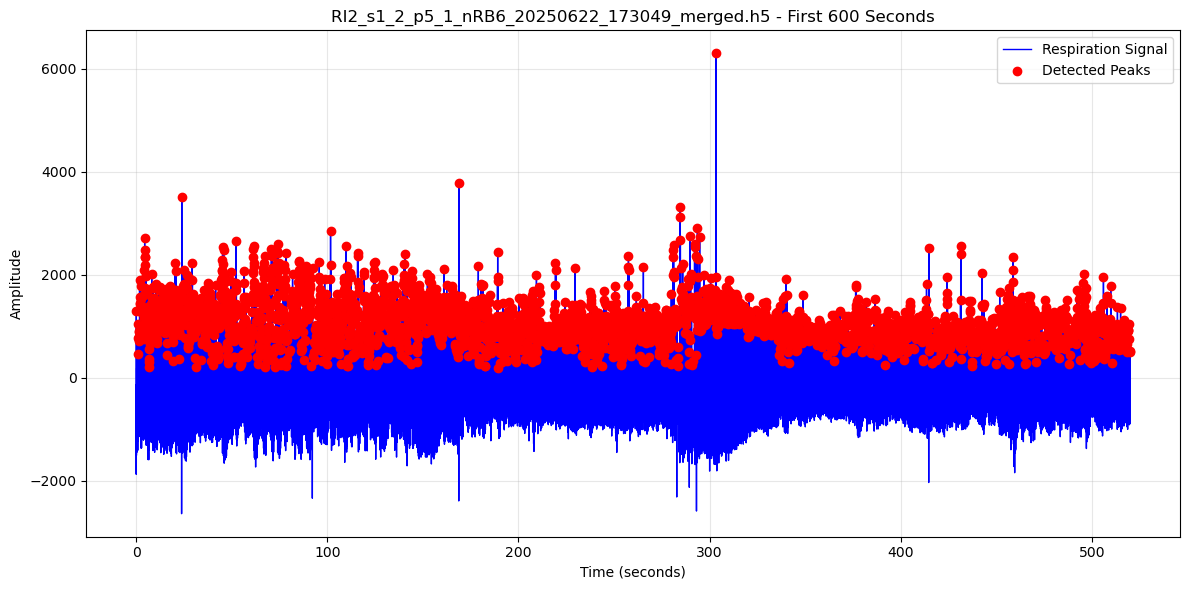

In [76]:
# Processing file: RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5
h5_file = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
result = analyze_and_plot_breathing(h5_file)